Set directories and parameters

In [118]:
### PATHS AND DIRECTORIES ###
# Location of .spec files
p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"
s_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral_s/01_compspec/SPECOUT/"

# Location of earthquake catalog containing stress drop estimates
delsig_catalog_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

# Location of spectra.pkl file/where to save it
spectra_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/"


### INPUT DATA PARAMETERS ###
components = ['z']
units = ['h', 'n']

# Beta computation params
low_f_range = [2, 5]
high_f_range = [20, 35]
stn_f_range = [2.5, 6.0]
nf = 76
dfreq = 2.0/3.0

stn_req = 3
nrecords_min = 1

dist_min = 0
dist_max = 120

xsec_dmax = 1500

# load_df = True
load_df = False

# perform a station correction, setting the median logbeta of these magnitudes
#     equal to zero for a single station
beta_shift_range = [1.4, 1.6]
# beta_shift_range = [1.9, 2.1]

calib_range = beta_shift_range
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10

# minimum number of events in the above range to perform the correction
# ncorr_min = 100
ncorr_min = 1



ncorr_max_r = 20
ncorr_max_z = 2 # max depth difference, +/-, km


In [100]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange


In [101]:
components = [el.upper() for el in components]
units = [el.upper() for el in units]


Define some functions

In [102]:
## DataFrame functions
def filter_stn(row, stn_req, dependents):
    # print(row)
    keep_bool = np.array(row['stn'])>=stn_req

    for el in dependents:
        row[el] = row[el][keep_bool]
    return row

def avg_dist(row):
    return np.mean(row['deldist'])


# def get_slope(row):
#     if len(row['qmag']) > 1:
#         m = fit_line_p_norm(np.array(row['qmag']), np.log10(row['beta']), 1)
#         return m[0], m[1]
#     else:
#         return np.nan, np.nan

def get_slope(row, edges):
    if len(row['qmag']) > 1:
        Xavg, Yavg = get_bins_and_averages(row['qmag'], np.log10(row['beta']), edges=edges, method='median')
        if len(Xavg) > 1:
            m = fit_line_p_norm(Xavg, Yavg, 1)
            return m[0], m[1]
        else:
            return np.nan, np.nan
    else:
        return np.nan, np.nan

## end DataFrame functions



def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def plot_poly(poly, ax, color='k'):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c=color)
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c=color)

def get_bins_and_averages(x, y, edges, method='mean'):
    """Calculates the average value y in bins along x binned by edges.

    Args:
        x (np.ndarray): variable to separate into bins
        y (np.ndarray): variable to calculate average of
        edges (np.ndarray): points along x to on which to bin
        method (str, optional): 'mean' or 'median'. Defaults to 'mean'.

    Returns:
        midpoints (np.ndarray): linear mean of the edges around the bin
        avg_bin (np.ndarray): average of the y values in the bin. 
    
    Notes:
        - formerly known as 'bin_data_average()'
    """
    ledges = edges[:-1]
    redges = edges[1:]
    midpoints = (ledges + redges)/2
    avg_bin = np.zeros(len(ledges), dtype=float)

    if method=='mean': avg_func = np.mean
    elif method=='median': avg_func = np.median
    for ii in np.arange(len(ledges)):
        bin_bool = np.logical_and(x >= ledges[ii], x < redges[ii])
        data = y[bin_bool]
        data = data[np.logical_not(np.isnan(data))]
        if len(data) > 0:
            avg_bin[ii] = avg_func(data)
        else:
            avg_bin[ii] = np.nan
    
    occupied_bool = np.logical_not(np.isnan(avg_bin))
    midpoints = midpoints[occupied_bool]
    avg_bin = avg_bin[occupied_bool]

    return midpoints, avg_bin

def compute_station_correction(row, m_range=[0,10]):

    logbeta = np.log10(row['beta'])
    mag = np.array(row['qmag'])

    inds = np.where(np.logical_and(mag>=m_range[0], mag<m_range[1]))[0]

    corr = np.median(logbeta[inds])

    return corr

def df_compute_logbeta(s, low_f_ind, high_f_ind, df):
    # this is slow af, don't use anymore
    if np.any(np.isnan(s)): return np.nan
    # assume a linear-scale (non-log) spectrum
    s_low = s[low_f_ind[0]:low_f_ind[1]+1]
    s_high = s[high_f_ind[0]:high_f_ind[1]+1]

    # log mean value
    low_avg =  np.mean(np.log10(s_low))
    high_avg = np.mean(np.log10(s_high))
    logbeta = high_avg - low_avg
    return logbeta

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

Load .spec files into a DataFrame

In [ ]:
data_dir_files = os.listdir(spectra_dir)

if "spectra.pkl" in data_dir_files:
    # load pre-computed df_all DataFrame if possible
    print(f"Loading spectra.pkl...")
    t0 = time.time()
    df_all = pd.read_pickle(spectra_dir+"spectra.pkl")
    print(f"    {len(df_all)} station-event pairs loaded from spectra.pkl (t = {time.time()-t0:.3f} s)")

else:
    spec_files = [el for el in os.listdir(p_spec_dir) if el.endswith('.spec')]
    nspec = len(spec_files)


    # Read all P-wave spectra files
    print(f"Reading P-wave .spec files from {p_spec_dir}")
    print("----------------------------------------")
    d = [[]] * nspec
    for i in trange(nspec):
        filename = spec_files[i]
        d[i] = read_spec_df(p_spec_dir+filename)
    print("Concatenating DataFrames...", end="")
    t0 = time.time()
    D_p = pd.concat(d)
    tf = time.time()
    print(f"Done ({tf-t0:.2f} s). {len(D_p)} records loaded. \n")

    # Rename to P-wave specific columns
    D_p = D_p.rename(columns={
        "s1": "p1",
        "s2": "p2",
        "nts": "nts_p"})


    ###


    s_spec_files = [el for el in os.listdir(s_spec_dir) if el.endswith('.spec')]
    s_nspec = len(s_spec_files)

    # Read all S-wave spectra files
    print(f"Reading S-wave .spec files from {s_spec_dir}")
    print("----------------------------------------")
    d = [[]] * s_nspec
    for i in trange(s_nspec):
        filename = s_spec_files[i]
        d[i] = read_spec_df(s_spec_dir+filename)
    print("Concatenating DataFrames...", end="")
    t0 = time.time()
    D_s = pd.concat(d)
    tf = time.time()
    print(f"Done ({tf-t0:.2f} s). {len(D_s)} records loaded. \n")

    # Rename to S-wave specific columns
    D_s = D_s.rename(columns={"nts": "nts_s"})

    # Merge the two dataframes together
    print("Merging P- and S-wave DataFrames...", end="")
    t0 = time.time()
    df_all = pd.merge(D_p, D_s, how='outer', on=['event_id', 'qlat', 'qlon', 'qdep','qdep','qmag','stid','slat','slon', 'selev', 'deldist'])
    tf = time.time()
    print(f"Done ({tf-t0:.2f} s). \n{len(df_all)} unique station-event pairs.\n")


    # Save the information as a pickle object
    print("Saving combined DataFrame...", end="")
    t0 = time.time()
    df_all.to_pickle(spectra_dir+"spectra.pkl")
    tf = time.time()
    print(f"Done ({tf-t0:.2f} s).")

    event_id = df['event_id'].values.astype(str)
    station_id = df['stname'].values
    nuniq = np.unique(event_id + station_id)
    assert nuniq == len(df), 'uh oh'

# need to make sure each line is a unique station-event pair


Load earthquake catalogs (for locations) and previous results (for stress drop)

In [ ]:

# real data
delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                    "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 
                    'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
delsig_cat = pd.read_csv(delsig_catalog_path, names=delsig_cat_names)
delsig_cat = delsig_cat[['event_id', 'delsig']]

# # synthetic data
# delsig_cat = pd.read_pickle('data/syn_cat.pkl')
# delsig_cat['event_id'] = delsig_cat['cuspid']
# delsig_cat = delsig_cat[['event_id', 'delsig', 'm0', 'fc']]


A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])



Read & plot the data Peter sent me

In [105]:
# names = [
#     "event_id",
#     "qyr",
#     "qmon",
#     "qday",
#     "qhr",
#     "qmn",
#     "qsc",
#     "qmag",
#     "qlat",
#     "qlon",
#     "qdep",
#     "negf",
#     "nbeta",
#     "dbeta_median"
# ]

# df_ps = pd.read_csv("data/out.beta", sep=r"\s+", names=names)
# bins = np.arange(1.0, 7.5, 0.2)

# df_ps['dbeta_corr'] = 0

# for i in range(len(bins)-1):
#     inbin = np.logical_and(df_ps['qmag']>=bins[i], df_ps['qmag']<bins[i+1])
#     if sum(inbin)>0:
#         df_ps['dbeta_corr'][inbin] = df_ps['dbeta_median'][inbin].values - np.median(df_ps['dbeta_median'][inbin])

# df_ps = pd.merge(df_ps, delsig_cat, on='event_id')



# plt.figure()
# # plt.scatter(df_ps['delsig'], df_ps['dbeta_median'], c='k', s=3, marker='.')
# sc = plt.scatter(df_ps['delsig'], df_ps['dbeta_corr'], c=df_ps['qmag'], s=3, marker='.')
# plt.xscale('log')
# plt.xlabel('Stress drop (MPa)')
# plt.ylabel("corrected dbeta")
# # plt.xlim([0.1, 1000])
# # plt.ylim([-1.5, 0.5])

# cbar = plt.colorbar(sc)
# cbar.ax.set_ylabel("Magnitude")
# plt.show()

# plt.figure()
# sc = plt.scatter(df_ps['qmag'], df_ps['dbeta_corr'], c='k', s=3, marker='.')
# plt.xlabel('Magnitude')
# plt.ylabel("Corrected dbeta")
# plt.show()


In [ ]:


f = np.arange(nf) * dfreq


low_f_ind = np.array([np.argmin(np.abs(f - el)) for el in low_f_range])
high_f_ind = np.array([np.argmin(np.abs(f - el)) for el in high_f_range])

i1, i2 = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_f_band = [f[i1], f[i2]]

stn_inds = [i1, i2]

low_f_band = f[low_f_ind]
high_f_band = f[high_f_ind]

print("")
print("FREQUENCY ARRAY INFORMATION")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print(f"Desired | Actual low-frequency band:   {low_f_range[0]:7.3f} -{low_f_range[1]:7.3f} Hz | {low_f_band[0]:7.3f} -{low_f_band[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band:  {high_f_range[0]:7.3f} -{high_f_range[1]:7.3f} Hz | {high_f_band[0]:7.3f} -{high_f_band[1]:7.3f} Hz")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_f_band[0]:7.3f} -{stn_f_band[1]:7.3f} Hz")

# print("Computing P-wave logbeta values...", end="")
# df_all['logbeta_p'] = df_all['p2'].apply(compute_logbeta, args=(low_f_ind, high_f_ind, df))
# print("Done.")
# print("Computing S-wave logbeta values...", end="")
# df_all['logbeta_s'] = df_all['s2'].apply(compute_logbeta, args=(low_f_ind, high_f_ind, df))
# print("Done.")

Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [ ]:
def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", "nts_p", "nts_s"]
dependents = ['deldist', 'p1', 'p2', 's1', 's2']

print("-----------------------------")
print("---    DATA PROCESSING    ---")
print("-----------------------------")

if all([el in data_dir_files for el in ['df.pkl', 'df_sta.pkl', 'df_ev.pkl']])\
    and load_df:
    # print("Loading pre-computed DataFrames. Change 'load_df' to False to"
    #     " re-compute.")
    # df = pd.read_pickle(data_dir + 'df.pkl')
    # df_sta = pd.read_pickle(data_dir + 'df_sta.pkl')
    # df_ev = pd.read_pickle(data_dir + 'df_ev.pkl')

    # st_dep += ['sx', 'sy', 'stind']
    # ev_dep += ['qx', 'qy', 'evind']
    # # dependents += ['distind', 'logbeta', 'logbeta_s']
    # dependents += ['logbeta']
    print('need to rewrite this')
    raise ValueError()
else:
    
    print("\nFiltering out records based on user-specified criteria...")
    print("---------------------------------------------------------")
    # df_ev is event-organized (one row per event)
    df = df_all.copy()
    df = df.rename(columns={"stid":"stname"})
    npairs_initial = len(df)

    # remove events below the lower shift range, since these are unused for all future steps
    t0 = time.time()
    df = df[df['qmag'] >= beta_shift_range[0]].reset_index(drop=True)
    npairs = len(df)
    print(f"{npairs_initial - npairs} pairs with qmag < M{beta_shift_range[0]:.2} removed (t = {time.time()-t0:.3f} s)")

    t0 = time.time()
    df['cha'] = df['stname'].apply(get_cha)
    df['component'] = df['cha'].apply(get_component)
    df['unit'] = df['cha'].apply(get_units)
    print(f"Computed cha, component, and unit columns ({time.time()-t0:.2} s)")

    # remove components not in 'components' object ('N', 'E', 'Z', for example)
    l1 = len(df)
    df = df[np.any([df['component'].values==el for el in components], axis=0)]
    print(f"{l1-len(df)} records removed (component not in {components})")

    # remove units not in 'unit' object ('H', 'N', for example)
    l1 = len(df)
    df = df[np.any([df['unit'].values==el for el in units], axis=0)]
    print(f"{l1-len(df)} records removed (unit not in {units})")

    # drop these columns
    df = df.drop(columns=['cha', 'component', 'unit']).reset_index(drop=True)

    # # explode!
    # df = df_sta.explode(ev_dep + dependents)
    df['event_id'] = df['event_id'].astype(int)
    df['qmag'] = df['qmag'].astype(float)
    df['qlat'] = df['qlat'].astype(float)
    df['qlon'] = df['qlon'].astype(float)
    df['qdep'] = df['qdep'].astype(float)
    df['slat'] = df['slat'].astype(float)
    df['slon'] = df['slon'].astype(float)
    df['selev'] = df['selev'].astype(float)
    df['deldist'] = df['deldist'].astype(float)
    df['nts_p'] = df['nts_p'].astype(float)
    df['nts_s'] = df['nts_s'].astype(float)
    
    # Compute sx and sy (station easting and northing)
    t0 = time.time()
    df['sx'], df['sy'], zn, zl = utm.from_latlon(
        df['slat'].values, 
        df['slon'].values
        )
    st_dep += ['sx', 'sy']
    df.reset_index(drop=True, inplace=True)

    # Compute qxs and qys of events (event eastings and northings)
    df['qx'], df['qy'], zn, zl = utm.from_latlon(
        df['qlat'].values, 
        df['qlon'].values
        )
    ev_dep += ['qx', 'qy']
    df.reset_index(drop=True, inplace=True)
    print(f"Earthquake and station eastings and westings computed (t = {time.time()-t0:.3f} s)")

    # # get number of initial events
    # nevents_initial = len(df['event_id'].unique())
    # print(f"{nevents_initial} events, recorded by {nstations_initial} "
    #     f"stations, resulting in {nrecords_initial} records loaded.")

    # # bin values by distance, first removing distant records
    # df = df[df['deldist']<=dist_max]
    # n_dmax_removed = nrecords_initial-len(df)
    # print(f"{n_dmax_removed} distant (>{dist_max:.1f} km) records "
    #     "removed")

    # df = df[df['deldist']>=dist_min]
    # n_dmmin_removed = nrecords_initial-len(df)+n_dmax_removed
    # print(f"{n_dmmin_removed} nearby (<{dist_min:.1f} km) records "
    #     "removed")

    # # filter out bad STN records
    # df = df[df['stn']>=stn_req]
    # df.reset_index(drop=True, inplace=True)
    # print(f"{len(df)} records ({len(df)/nrecords_initial*100:.1f}%) passed "
    #     f"STN ratio requirement of {stn_req:.1f}")

    # # make sure each earthquake has enough remaining records
    # df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
    # df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
    # print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
    #     f" records (needs >= {nrecords_min})")

    # # for each target event, find calibration events
    # nev = len(df_ev)

    # group by station to add index
    df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

    df_sta['stind'] = df_sta.index.values.astype(int)
    st_dep += ['stind']
    df = df_sta.explode(ev_dep + dependents)
    df.reset_index(drop=True, inplace=True)

    df['event_id'] = df['event_id'].astype(int)
    df['qmag'] = df['qmag'].astype(float)
    df['qlat'] = df['qlat'].astype(float)
    df['qlon'] = df['qlon'].astype(float)
    df['qdep'] = df['qdep'].astype(float)
    df['slat'] = df['slat'].astype(float)
    df['slon'] = df['slon'].astype(float)
    df['selev'] = df['selev'].astype(float)
    df['deldist'] = df['deldist'].astype(float)
    df['nts_p'] = df['nts_p'].astype(float)
    df['nts_s'] = df['nts_s'].astype(float)
    df['qx'] = df['qx'].astype(float)
    df['qy'] = df['qy'].astype(float)
    df['sx'] = df['sx'].astype(float)
    df['sy'] = df['sy'].astype(float)

    # save the events within calibration M range for later
    df_calib = df[np.logical_and(df['qmag'] >= calib_range[0], df['qmag'] < calib_range[1])].reset_index(drop=True)

    # group by event
    df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

    # # Save DataFrames
    # print("Saving DataFrames...")
    # t0 = time.time()
    # df.to_pickle(data_dir + "df.pkl")
    # print(f"    Saved df to {data_dir + 'df.pkl'}")
    # df_sta.to_pickle(data_dir + "df_sta.pkl")
    # print(f"    Saved df_sta to {data_dir + 'df_sta.pkl'}")
    # df_ev.to_pickle(data_dir + "df_ev.pkl")
    # print(f"    Saved df_ev to {data_dir + 'df_ev.pkl'}")
    # print(f"Done (t = {time.time()-t0:.2} s)")



nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)


print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents} events")
print(f"{nstations} stations")
print(f"{ndata} records")


In [108]:
## Compute logbeta values for P- and S-wave spectra

# find indices where spectra are non-NaN, stack into 2D-array
inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
p2 = np.vstack(df['p2'].values[inds], dtype=float)

# compute logbeta for each row in the 2D-array
logbeta = compute_logbeta(p2, low_f_ind, high_f_ind)
df['logbeta_p'] = np.nan 
df.loc[inds, 'logbeta_p'] = logbeta

inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
s2 = np.vstack(df['s2'].values[inds], dtype=float)

logbeta = compute_logbeta(s2, low_f_ind, high_f_ind)
df['logbeta_s'] = np.nan 
df.loc[inds, 'logbeta_s'] = logbeta

dependents += ['logbeta_p', 'logbeta_s']

In [109]:
## Compute STN values for P- and S-wave spectra

# find indices where spectra are non-NaN, stack into 2D-array
# should get equivalent result using either p1 or p2 columns
inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
p2 = np.vstack(df['p2'].values[inds], dtype=float)
p1 = np.vstack(df['p1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn = compute_stn(p2, p1, stn_inds)
df['stn_p'] = np.nan 
df.loc[inds, 'stn_p'] = stn

# now for S-wave spectra
inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
s2 = np.vstack(df['s2'].values[inds], dtype=float)
s1 = np.vstack(df['s1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn = compute_stn(s2, s1, stn_inds)
df['stn_s'] = np.nan 
df.loc[inds, 'stn_s'] = stn

dependents += ['stn_p', 'stn_s']

Visualize the signal-to-noise of the calibration event records

In [ ]:
bins = np.arange(-5, 20, 0.25)
logbins = np.arange(-2, 4, 0.1)

df_calib = df[np.logical_and(df['qmag']>=calib_range[0], df['qmag']<calib_range[1])].reset_index(drop=True)

plt.figure()
plt.hist((df_calib['stn_p']), bins=bins, histtype='step', color='b')
plt.hist((df_calib['stn_s']), bins=bins, histtype='step', color='r')
plt.axvline(calib_stn_req, color='k')
plt.show()

plt.figure()
plt.hist(np.log10(df_calib['stn_p']), bins=logbins, histtype='step', color='b')
plt.hist(np.log10(df_calib['stn_s']), bins=logbins, histtype='step', color='r')
plt.axvline(np.log10(calib_stn_req), color='k')
plt.show()



In [ ]:
# Perform corrections using calibration events

phase = 'p' 

if phase == 'p':
    logbeta_name = 'logbeta_p' 
    stn_name = 'stn_p'
elif phase == 's':
    logbeta_name = 'logbeta_s'
    stn_name = 'stn_s' 

df_calib = df[np.logical_and(df['qmag']>=calib_range[0], df['qmag']<calib_range[1])].reset_index(drop=True)

df_target = df_ev[df_ev['qmag'] >= calib_range[1]].reset_index(drop=True)
df_target['dlogbeta'] = np.nan
print(f"{len(df_target)} total target events (M >= {calib_range[1]:.2f})")

# loop over each target event
for i in trange(len(df_target)):

    # Store the entire row of the target event
    row = df_target.loc[i]

    # Store a copy of the calibration event records DataFrame
    df_c = df_calib.copy()

    # Get all records in df relating to target event_id
    df_t = df[df['event_id'] == row['event_id']].reset_index(drop=True)

    # Filter out calibration event records that:
    #   1) are too shallow or too deep
    #   2) don't share stations with the target event
    #   3) are too low signal-to-noise ratio
    keep_bool = np.all([
        df_c['qdep']>=row['qdep']-calib_zmax, 
        df_c['qdep']<=row['qdep']+calib_zmax,
        np.isin(df_c['stind'].values, row['stind']),
        df_c[stn_name] >= calib_stn_req,
        ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)

    # rough filter to avoid computing distances for all calibration events (test)
    keep_bool = np.all([
        np.abs(df_c['qx']-row['qx']) <= calib_rmax*1000,
        np.abs(df_c['qy']-row['qy']) <= calib_rmax*1000,
    ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)

    df_c['tdist'] = np.sqrt((row['qx'] - df_c['qx'].values)**2 + (row['qy'] - df_c['qy'].values)**2)

    df_c = df_c[df_c['tdist'] <= calib_rmax*1000].reset_index(drop=True)

    evids = np.unique(df_c['event_id'].values)
    ncalib = len(evids)
    # print(ncalib)

    df_c = df_c[['stname','stind', 'event_id', logbeta_name]]

    if ncalib >= ncalib_min:

        df_t = pd.merge(df_t, df_c, how='inner', on='stind', suffixes=['_t','_c'])
        df_t['dlogbeta'] = df_t[f'{logbeta_name}_t'] - df_t[f'{logbeta_name}_c']

        df_target.at[i,'dlogbeta'] = np.median(df_t['dlogbeta'])



df_target = df_target[~np.isnan(df_target['dlogbeta'])].reset_index(drop=True)


In [ ]:
df_target = df_target[~np.isnan(df_target['dlogbeta'])].reset_index(drop=True)

edges = np.arange(1, 7.3, 0.2)
df_target['dlogbeta_corr'] = df_target['dlogbeta'].values

for i in range(len(edges)-1):
    inrange = np.logical_and(df_target['qmag']>=edges[i], df_target['qmag']<edges[i+1])
    dlogbetas = df_target[inrange]['dlogbeta'].values
    df_target.loc[inrange, 'dlogbeta_corr'] -= np.nanmedian(dlogbetas)
    # print(sum(np.isnan(dlogbetas)))

plt.figure()
plt.hist(df_target['dlogbeta'], 50)
plt.show()

ds = pd.merge(df_target, delsig_cat, on='event_id')
# ds = ds[ds['qmag'] >= 2.0]
ds = ds[~np.isnan(ds['dlogbeta_corr'])]



corrcoef = np.corrcoef(np.log10(ds['delsig'].values), ds['dlogbeta_corr'].values)[0,1]

txt = '\n'.join([
    f"correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_range[0]:.1f}<M<{calib_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"n calib. minimum: {ncalib_min}"
])

plt.figure()
ax = plt.gca()
plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.show()


In [ ]:
low_f_ind

In [ ]:
high_f_ind

In [ ]:
f[15]

# Loop over different combinations of low, high frequency bands

52 combinations of frequency bands
Range of low bands:  [1 6] [4 9]
Range of high bands:  [15 26] [39 50]
[[1 6]
 [2 7]
 [3 8]
 [4 9]]
[[15 26]
 [17 28]
 [19 30]
 [21 32]
 [23 34]
 [25 36]
 [27 38]
 [29 40]
 [31 42]
 [33 44]
 [35 46]
 [37 48]
 [39 50]]
Computing STN for all records...Done. (15.539 s)


------------------------------
1 of 52 iterations
------------------------------
6736 total target events (M >= 1.60)


100%|██████████| 6736/6736 [04:07<00:00, 27.17it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

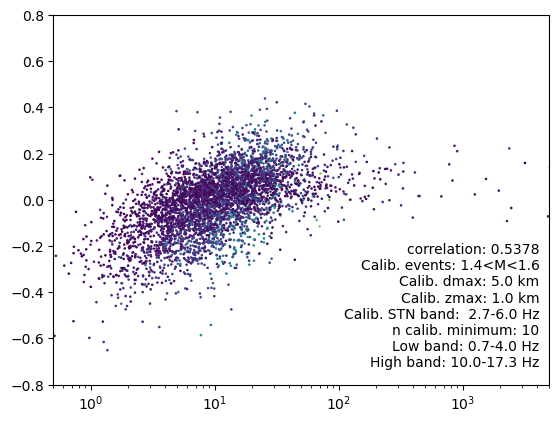



------------------------------
2 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:51<00:00, 35.59it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

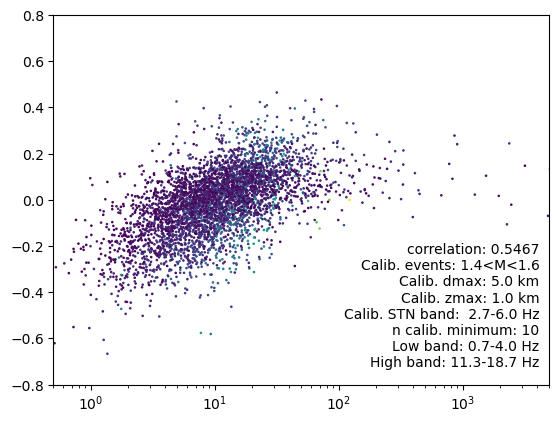



------------------------------
3 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:47<00:00, 36.39it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

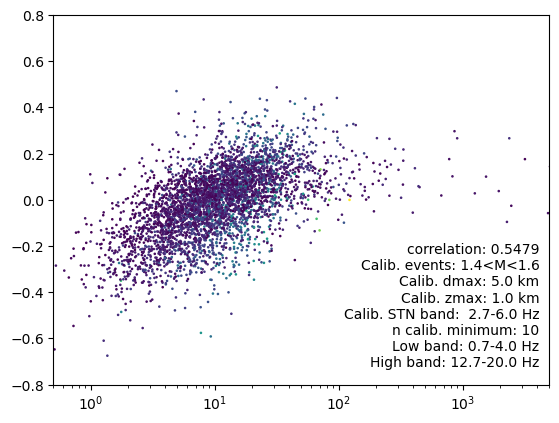



------------------------------
4 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:47<00:00, 36.32it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

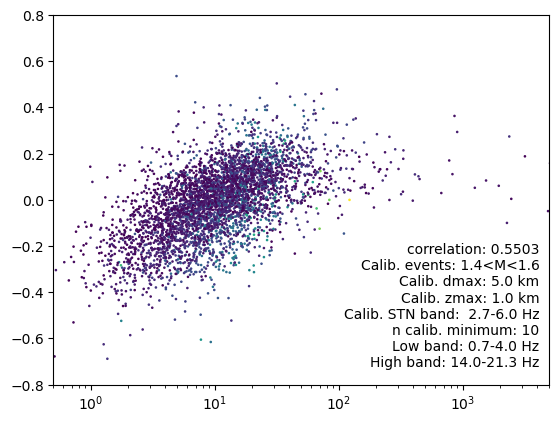



------------------------------
5 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:48<00:00, 36.07it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

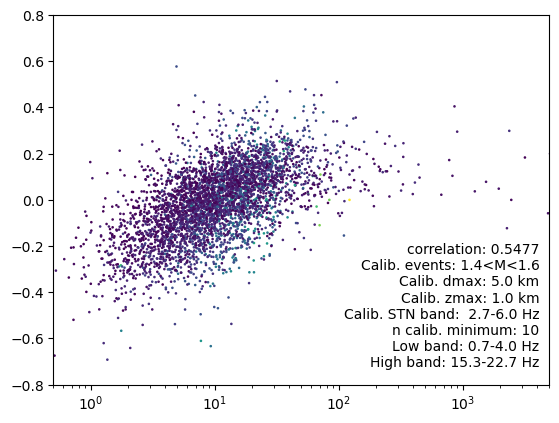



------------------------------
6 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:49<00:00, 36.01it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

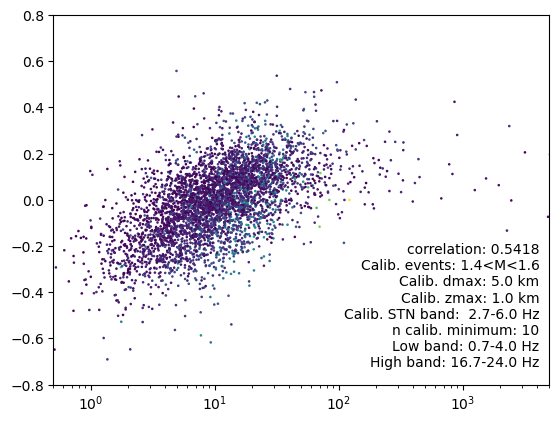



------------------------------
7 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:47<00:00, 36.35it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

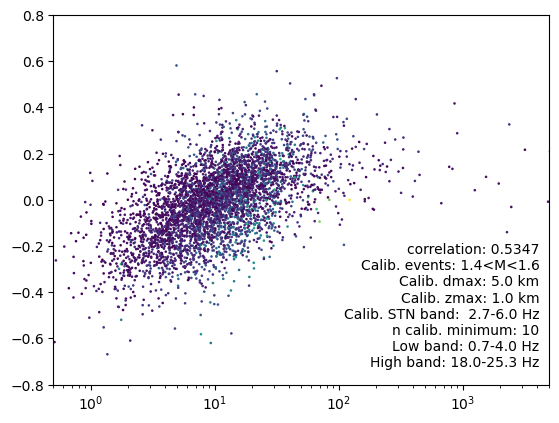



------------------------------
8 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:48<00:00, 36.10it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

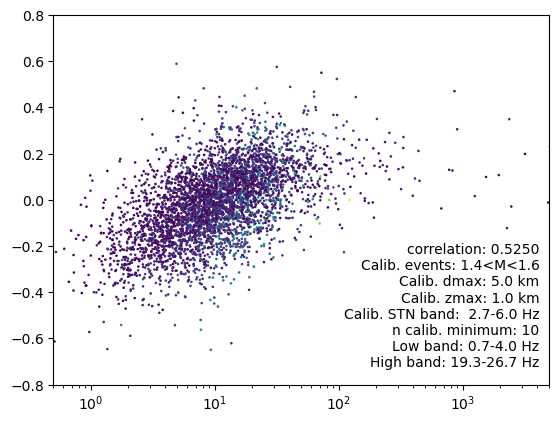



------------------------------
9 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:49<00:00, 35.90it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

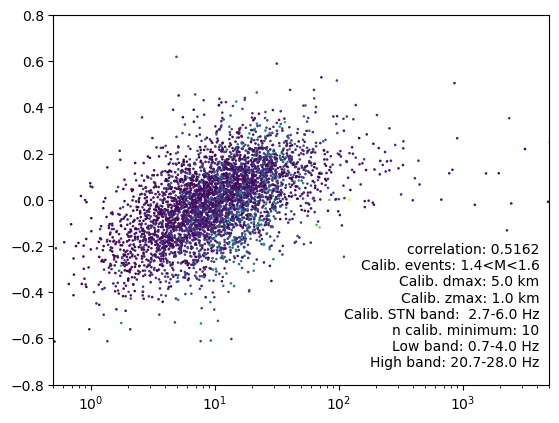



------------------------------
10 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:51<00:00, 35.46it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

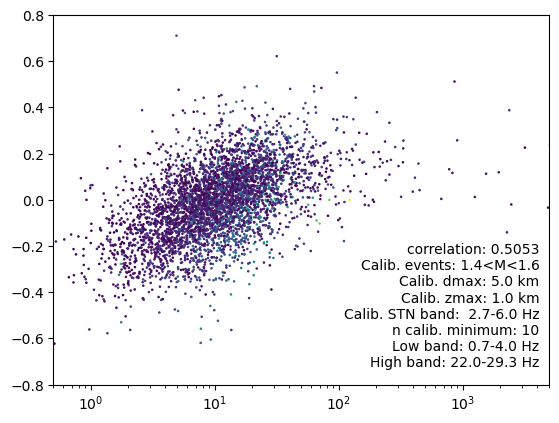



------------------------------
11 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:47<00:00, 36.37it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

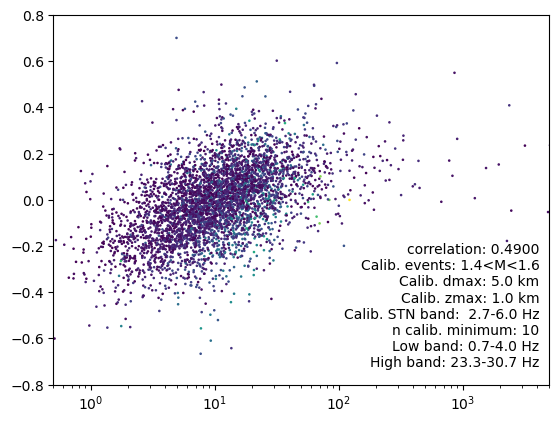



------------------------------
12 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:45<00:00, 36.81it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

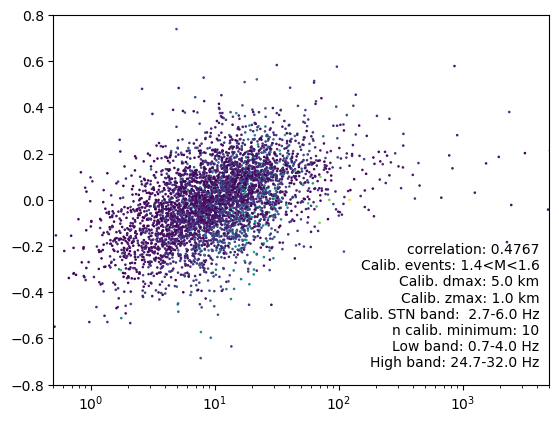



------------------------------
13 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:45<00:00, 36.70it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

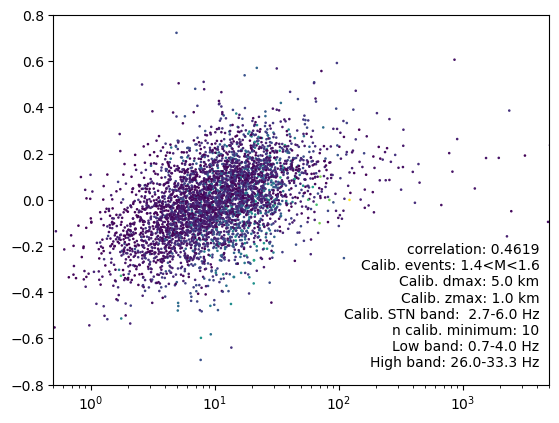



------------------------------
14 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:47<00:00, 36.40it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

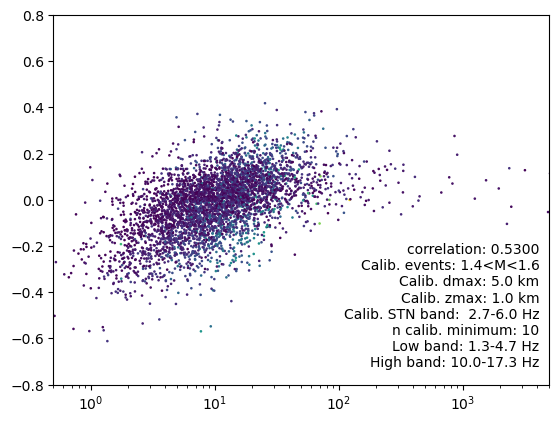



------------------------------
15 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [02:53<00:00, 35.19it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

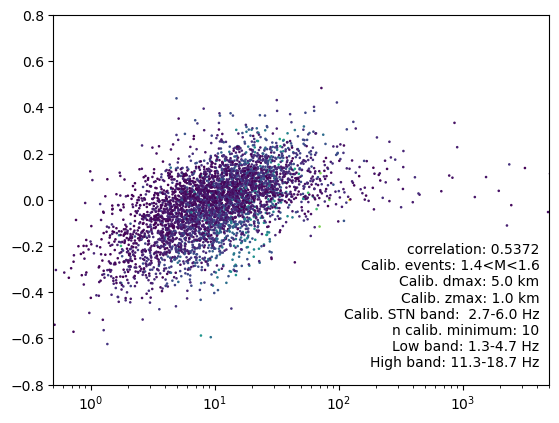



------------------------------
16 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [03:06<00:00, 32.59it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

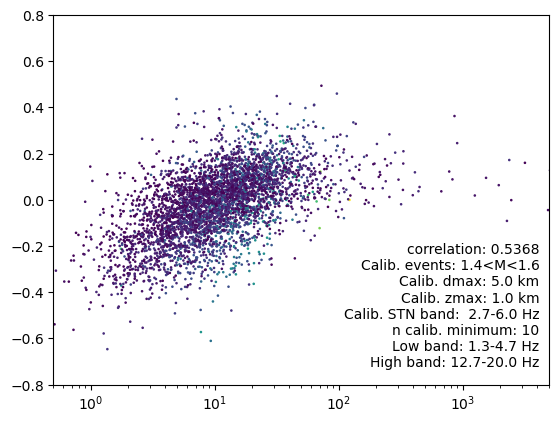



------------------------------
17 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [03:19<00:00, 30.49it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

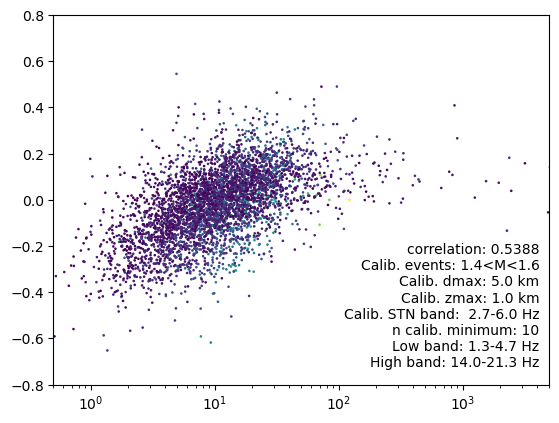



------------------------------
18 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [03:10<00:00, 31.99it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

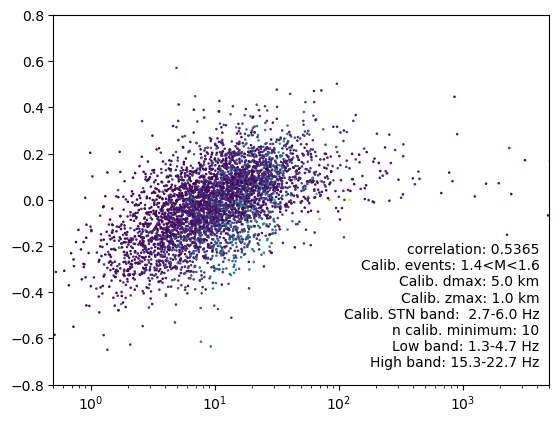



------------------------------
19 of 52 iterations
------------------------------
6090 total target events (M >= 1.60)


100%|██████████| 6090/6090 [03:33<00:00, 28.59it/s]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/_nanfunctions_

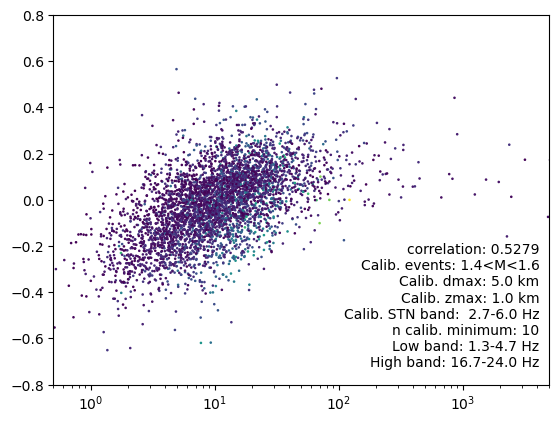



------------------------------
20 of 52 iterations
------------------------------


KeyboardInterrupt: 

In [262]:
# number of indices in each band
nf_low = 6
# nf_high = 24 
nf_high = 12 

di = 1
dj = 2

# lowest allowed index for each band
if0_low = 1     # 0.667 Hz
if0_high = 15   # 10 Hz

# highest allowed index for each band (inclusive)
if1_low = 9
if1_high = 51

phase = 's' 

low_f_inds  = [0, nf_low-1] + np.arange(if0_low, if1_low+2-nf_low, di)[:, np.newaxis]
high_f_inds = [0, nf_high-1] + np.arange(if0_high, if1_high+2-nf_high, dj)[:, np.newaxis]

nlow = len(low_f_inds)
nhigh = len(high_f_inds)

N = int(nlow * nhigh)

print(f"{N} combinations of frequency bands")

print("Range of low bands: ", low_f_inds[0], low_f_inds[-1])
print("Range of high bands: ", high_f_inds[0], high_f_inds[-1])
print(low_f_inds)
print(high_f_inds)

# raise ValueError()

### STN is the same for all i, j - compute it once
## Compute STN values for P- and S-wave spectra

# find indices where spectra are non-NaN, stack into 2D-array
# should get equivalent result using either p1 or p2 columns
print("Computing STN for all records...", end='')
t0 = time.time()
inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
p2 = np.vstack(df['p2'].values[inds], dtype=float)
p1 = np.vstack(df['p1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn_p = compute_stn(p2, p1, stn_inds)
df['stn_p'] = np.nan 
df.loc[inds, 'stn_p'] = stn_p

# now for S-wave spectra
inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
s2 = np.vstack(df['s2'].values[inds], dtype=float)
s1 = np.vstack(df['s1'].values[inds], dtype=float)

# compute stn for each row in the 2D-array
stn_s = compute_stn(s2, s1, stn_inds)
df['stn_s'] = np.nan 
df.loc[inds, 'stn_s'] = stn_s
print(f"Done. ({time.time()-t0:.3f} s)")


# 
df_target = df_ev[df_ev['qmag'] >= calib_range[1]].reset_index(drop=True)

df_target['df_calib_inds'] = np.zeros(len(df_target), dtype=object)


dependents += ['stn_p', 'stn_s']

corr = np.zeros((nlow, nhigh), dtype=float)
n = 0
for i in range(nlow):
    low_f_ind = low_f_inds[i]
    for j in range(nhigh):

        print("\n")
        print("------------------------------")
        print(f"{n+1} of {N} iterations")
        print("------------------------------")

        high_f_ind = high_f_inds[j]
            
        ## Compute logbeta values for P- and S-wave spectra

        # find indices where spectra are non-NaN, stack into 2D-array
        inds = np.where([hasattr(el, '__len__') for el in df['p2'].values ])[0]
        p2 = np.vstack(df['p2'].values[inds], dtype=float)

        # compute logbeta for each row in the 2D-array
        logbeta = compute_logbeta(p2, low_f_ind, high_f_ind)
        df['logbeta_p'] = np.nan 
        df.loc[inds, 'logbeta_p'] = logbeta

        inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
        s2 = np.vstack(df['s2'].values[inds], dtype=float)

        logbeta = compute_logbeta(s2, low_f_ind, high_f_ind)
        df['logbeta_s'] = np.nan 
        df.loc[inds, 'logbeta_s'] = logbeta

        dependents += ['logbeta_p', 'logbeta_s']


        # Perform corrections using calibration events

        if phase == 'p':
            logbeta_name = 'logbeta_p' 
            stn_name = 'stn_p'
        elif phase == 's':
            logbeta_name = 'logbeta_s'
            stn_name = 'stn_s' 

        df_calib = df[np.logical_and(df['qmag']>=calib_range[0], df['qmag']<calib_range[1])].reset_index(drop=True)

        df_target['dlogbeta'] = np.nan
        print(f"{len(df_target)} total target events (M >= {calib_range[1]:.2f})")

        if n == 0:
            # loop over each target event
            for l in trange(len(df_target)):

                # Store the entire row of the target event
                row = df_target.loc[l]

                # Store a copy of the calibration event records DataFrame
                df_c = df_calib.copy()

                # Get all records in df relating to target event_id
                df_t = df[df['event_id'] == row['event_id']].reset_index(drop=True)

                # Filter out calibration event records that:
                #   1) are too shallow or too deep
                #   2) don't share stations with the target event
                #   3) are too low signal-to-noise ratio
                keep_bool = np.all([
                    df_c['qdep']>=row['qdep']-calib_zmax, 
                    df_c['qdep']<=row['qdep']+calib_zmax,
                    np.isin(df_c['stind'].values, row['stind']),
                    df_c[stn_name] >= calib_stn_req,
                    ], axis=0)
                df_c = df_c[keep_bool].reset_index()

                # rough filter to avoid computing distances for all calibration events (test)
                keep_bool = np.all([
                    np.abs(df_c['qx']-row['qx']) <= calib_rmax*1000,
                    np.abs(df_c['qy']-row['qy']) <= calib_rmax*1000,
                ], axis=0)
                df_c = df_c[keep_bool].reset_index(drop=True)

                df_c['tdist'] = np.sqrt((row['qx'] - df_c['qx'].values)**2 + (row['qy'] - df_c['qy'].values)**2)

                df_c = df_c[df_c['tdist'] <= calib_rmax*1000].reset_index(drop=True)

                evids = np.unique(df_c['event_id'].values)
                ncalib = len(evids)
                # print(ncalib)

                df_c = df_c[['stname','stind', 'event_id', 'index', logbeta_name]]

                if ncalib >= ncalib_min:

                    df_t = pd.merge(df_t, df_c, how='inner', on='stind', suffixes=['_t','_c'])
                    df_t['dlogbeta'] = df_t[f'{logbeta_name}_t'] - df_t[f'{logbeta_name}_c']

                    df_target.at[l,'dlogbeta'] = np.median(df_t['dlogbeta'])

                    df_target.at[l, 'df_calib_inds'] = df_c['index'].values

        else:
            for l in trange(len(df_target)):
                row = df_target.loc[l]
                df_t = df[df['event_id'] == row['event_id']].reset_index(drop=True)

                df_c = df_calib.copy()

                df_c = df_c.iloc[df_target.at[l, 'df_calib_inds']].reset_index(drop=True)
                df_c = df_c[['stname','stind', 'event_id', logbeta_name]]

                evids = np.unique(df_c['event_id'].values)
                ncalib = len(evids)

                if ncalib >= ncalib_min:

                    df_t = pd.merge(df_t, df_c, how='inner', on='stind', suffixes=['_t','_c'])
                    df_t['dlogbeta'] = df_t[f'{logbeta_name}_t'] - df_t[f'{logbeta_name}_c']

                    df_target.at[l,'dlogbeta'] = np.median(df_t['dlogbeta'])
                # raise ValueError()
        


        df_target = df_target[~np.isnan(df_target['dlogbeta'])].reset_index(drop=True)

        edges = np.arange(1, 7.3, 0.2)
        df_target['dlogbeta_corr'] = df_target['dlogbeta'].values

        for l in range(len(edges)-1):
            inrange = np.logical_and(df_target['qmag']>=edges[l], df_target['qmag']<edges[l+1])
            dlogbetas = df_target[inrange]['dlogbeta'].values
            df_target.loc[inrange, 'dlogbeta_corr'] -= np.nanmedian(dlogbetas)
            # print(sum(np.isnan(dlogbetas)))

        ds = pd.merge(df_target, delsig_cat, on='event_id')
        # ds = ds[ds['qmag'] >= 2.0]
        ds = ds[~np.isnan(ds['dlogbeta_corr'])]

        corrcoef = np.corrcoef(np.log10(ds['delsig'].values), ds['dlogbeta_corr'].values)[0,1]

        corr[i, j] = corrcoef

        txt = '\n'.join([
            f"correlation: {corrcoef:.4f}", 
            f"Calib. events: {calib_range[0]:.1f}<M<{calib_range[1]:.1f}",
            f"Calib. dmax: {calib_rmax:.1f} km",
            f"Calib. zmax: {calib_zmax:.1f} km",
            f"Calib. STN band:  {stn_f_band[0]:.1f}-{stn_f_band[1]:.1f} Hz",
            f"n calib. minimum: {ncalib_min}",
            f"Low band: {f[low_f_ind[0]]:.1f}-{f[low_f_ind[1]]:.1f} Hz",
            f"High band: {f[high_f_ind[0]]:.1f}-{f[high_f_ind[1]]:.1f} Hz",
        ])

        plt.figure()
        ax = plt.gca()
        plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
        plt.xscale('log')
        plt.ylim([-0.8, 0.8])
        plt.xlim([0.5, 5000.0])
        ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
        plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
        plt.show()

        n += 1
np.save('data/corr.npy', corr)

In [260]:
df_c.iloc[df_target.at[l, 'df_calib_inds']]

,stname,slat,slon,selev,sx,sy,event_id,qmag,qlon,qlat,...,deldist,p1,p2,s1,s2,stind,logbeta_p,logbeta_s,stn_p,stn_s
238,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38449607,1.43,-117.590714,35.614731,...,71.709259,"[2.448036440227952e-08, 5.7637098649365726e-08...","[1.3010742350161308e-06, 6.332973612188653e-07...","[1.88681710255878e-08, 2.4151074029532538e-08,...","[1.064551497620414e-06, 6.307574835773266e-07,...",7,0.888006,0.617515,3.012109,1.213503
554,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38483639,1.57,-117.544731,35.672649,...,71.032082,"[4.778802420446482e-08, 6.415010034288571e-08,...","[5.45876503110776e-07, 2.5919140966834675e-07,...","[1.0606792244516328e-07, 9.349035678951623e-08...","[2.0246309873073187e-07, 6.289563714290125e-08...",7,0.122363,0.842319,3.045286,0.563718
1519,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38563447,1.50,-117.550987,35.676899,...,71.760727,"[8.402395934581364e-08, 3.014721272620591e-08,...","[5.281949029267707e-07, 1.994014695583246e-07,...","[2.479805516486522e-07, 2.493899557975965e-07,...","[1.830577389227983e-06, 9.200365980177594e-07,...",7,0.710698,0.844874,3.612752,1.005908
3354,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38451719,1.42,-117.587997,35.619068,...,64.768936,"[1.4537945292047993e-09, 4.279304688381558e-10...","[3.540148441061319e-08, 2.553018774165139e-08,...","[1.3109542784661699e-08, 2.7045537365211203e-0...","[1.4621629418343218e-07, 1.0430152030949102e-0...",10,-0.659225,-0.466409,6.528166,0.573387
3364,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38452343,1.45,-117.551041,35.655170,...,69.983276,"[2.4902084838629435e-09, 5.3855790937973325e-0...","[1.069090274086193e-07, 6.120221485161892e-08,...","[2.5458932739752527e-09, 5.869792651935768e-09...","[4.544798670735872e-08, 3.746096410850441e-08,...",10,-0.875682,-1.052889,4.435106,3.417582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125527,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38552887,1.48,-117.524437,35.665138,...,10.388426,"[4.779084239459053e-09, 3.05190051008708e-09, ...","[9.989824434342154e-08, 5.302338479395985e-08,...","[2.09933972428189e-08, 1.410450511940553e-08, ...","[1.5094769878487568e-07, 9.181509597055992e-08...",146,-0.076052,0.369603,8.926112,4.433620
125561,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38555279,1.58,-117.559677,35.678349,...,13.484076,"[5.553437265604089e-09, 4.827869659607131e-09,...","[8.283926433705346e-08, 4.3983710895645345e-08...","[1.0944224193565333e-08, 8.56463966414367e-09,...","[5.5748905936070514e-08, 3.183508923143563e-08...",146,0.265682,0.506425,6.495881,1.140466
125589,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38557847,1.50,-117.532837,35.681721,...,12.351384,"[9.914541410083189e-10, 6.579498057490696e-10,...","[3.3813878363986305e-09, 3.3891411899134027e-0...","[1.1759141438361098e-09, 1.0947893702706324e-0...","[5.2860677612898144e-08, 4.4964494350097084e-0...",146,0.500453,0.253398,19.287891,1.674848
125675,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38567887,1.54,-117.551682,35.642799,...,10.234350,"[4.124042884967594e-09, 3.4528393477728514e-09...","[2.7504787780685547e-08, 1.3919221331093468e-0...","[1.7771468741045737e-09, 1.175358388394443e-08...","[7.320647910091793e-08, 4.746876669514677e-08,...",146,0.475725,0.072516,10.078783,7.818161


In [257]:
ncalib

36

In [255]:
df_target.at[l, 'df_calib_inds']

array([   238,    554,   1519,   3354,   3364,   3378,   3427,   5835,
         5886,   5931,   5948,   6026,   6069,   6093,   6109,   6137,
         6143,   6158,   6349,   6575,   6644,   6770,   6844,   6969,
         6998,   7058,   7109,   7170,   7227,   7261,   7342,   7375,
         7567,   7578,   7627,   7671,   7688,   7738,   7766,   7808,
         7841,   7846,   7894,   8082,   8300,   8366,   8555,   8758,
         8807,   8864,   8918,   8951,   8979,   9028,   9060,   9247,
        11733,  11756,  11802,  11817,  11930,  11940,  11954,  11998,
        12004,  12019,  12206,  12420,  12507,  12610,  12683,  12863,
        12916,  13088,  13175,  13560,  14031,  14303,  14489,  17503,
        17526,  17576,  17591,  18179,  20593,  20751,  20811,  20821,
        21294,  21674,  21701,  21918,  21952,  24005,  26882,  27144,
        27668,  27757,  28443,  28568,  28768,  28973,  33416,  33421,
        33784,  34176,  35267,  35407,  35448,  35471,  35487,  35519,
      

In [245]:
df_c = df_calib.copy()

# Get all records in df relating to target event_id
df_t = df[df['event_id'] == row['event_id']].reset_index(drop=True)

# Filter out calibration event records that:
#   1) are too shallow or too deep
#   2) don't share stations with the target event
#   3) are too low signal-to-noise ratio
keep_bool = np.all([
    df_c['qdep']>=row['qdep']-calib_zmax, 
    df_c['qdep']<=row['qdep']+calib_zmax,
    np.isin(df_c['stind'].values, row['stind']),
    df_c[stn_name] >= calib_stn_req,
    ], axis=0)
df_c = df_c[keep_bool].reset_index()

# rough filter to avoid computing distances for all calibration events (test)
keep_bool = np.all([
    np.abs(df_c['qx']-row['qx']) <= calib_rmax*1000,
    np.abs(df_c['qy']-row['qy']) <= calib_rmax*1000,
], axis=0)
df_c = df_c[keep_bool].reset_index(drop=True)

In [246]:
iii = df_c['index'].values
df_c

,index,stname,slat,slon,selev,sx,sy,event_id,qmag,qlon,...,deldist,p1,p2,s1,s2,stind,logbeta_p,logbeta_s,stn_p,stn_s
0,238,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38449607,1.43,-117.590714,...,71.709259,"[2.448036440227952e-08, 5.7637098649365726e-08...","[1.3010742350161308e-06, 6.332973612188653e-07...","[1.88681710255878e-08, 2.4151074029532538e-08,...","[1.064551497620414e-06, 6.307574835773266e-07,...",7,0.888006,0.893020,3.012109,1.213503
1,554,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38483639,1.57,-117.544731,...,71.032082,"[4.778802420446482e-08, 6.415010034288571e-08,...","[5.45876503110776e-07, 2.5919140966834675e-07,...","[1.0606792244516328e-07, 9.349035678951623e-08...","[2.0246309873073187e-07, 6.289563714290125e-08...",7,0.441903,0.852282,3.045286,0.563718
2,1519,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38563447,1.50,-117.550987,...,71.760727,"[8.402395934581364e-08, 3.014721272620591e-08,...","[5.281949029267707e-07, 1.994014695583246e-07,...","[2.479805516486522e-07, 2.493899557975965e-07,...","[1.830577389227983e-06, 9.200365980177594e-07,...",7,0.721867,0.957358,3.612752,1.005908
3,3354,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38451719,1.42,-117.587997,...,64.768936,"[1.4537945292047993e-09, 4.279304688381558e-10...","[3.540148441061319e-08, 2.553018774165139e-08,...","[1.3109542784661699e-08, 2.7045537365211203e-0...","[1.4621629418343218e-07, 1.0430152030949102e-0...",10,-0.422727,-0.362000,6.528166,0.573387
4,3364,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38452343,1.45,-117.551041,...,69.983276,"[2.4902084838629435e-09, 5.3855790937973325e-0...","[1.069090274086193e-07, 6.120221485161892e-08,...","[2.5458932739752527e-09, 5.869792651935768e-09...","[4.544798670735872e-08, 3.746096410850441e-08,...",10,-0.690625,-0.886401,4.435106,3.417582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,125561,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38555279,1.58,-117.559677,...,13.484076,"[5.553437265604089e-09, 4.827869659607131e-09,...","[8.283926433705346e-08, 4.3983710895645345e-08...","[1.0944224193565333e-08, 8.56463966414367e-09,...","[5.5748905936070514e-08, 3.183508923143563e-08...",146,0.260709,0.506425,6.495881,1.140466
650,125589,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38557847,1.50,-117.532837,...,12.351384,"[9.914541410083189e-10, 6.579498057490696e-10,...","[3.3813878363986305e-09, 3.3891411899134027e-0...","[1.1759141438361098e-09, 1.0947893702706324e-0...","[5.2860677612898144e-08, 4.4964494350097084e-0...",146,0.500453,0.196438,19.287891,1.674848
651,125675,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38567887,1.54,-117.551682,...,10.234350,"[4.124042884967594e-09, 3.4528393477728514e-09...","[2.7504787780685547e-08, 1.3919221331093468e-0...","[1.7771468741045737e-09, 1.175358388394443e-08...","[7.320647910091793e-08, 4.746876669514677e-08,...",146,0.540634,0.121900,10.078783,7.818161
652,125743,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38574815,1.44,-117.602188,...,13.040750,"[2.487926253902373e-10, 1.0629572777531848e-09...","[3.7817084574953697e-08, 2.1823504781082192e-0...","[3.6001606140700915e-09, 3.842682616550519e-09...","[9.341252393824107e-08, 4.601230330081307e-08,...",146,0.197582,0.176853,5.319378,3.888431


In [247]:
df_calib.loc[iii]

,stname,slat,slon,selev,sx,sy,event_id,qmag,qlon,qlat,...,deldist,p1,p2,s1,s2,stind,logbeta_p,logbeta_s,stn_p,stn_s
238,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38449607,1.43,-117.590714,35.614731,...,71.709259,"[2.448036440227952e-08, 5.7637098649365726e-08...","[1.3010742350161308e-06, 6.332973612188653e-07...","[1.88681710255878e-08, 2.4151074029532538e-08,...","[1.064551497620414e-06, 6.307574835773266e-07,...",7,0.888006,0.893020,3.012109,1.213503
554,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38483639,1.57,-117.544731,35.672649,...,71.032082,"[4.778802420446482e-08, 6.415010034288571e-08,...","[5.45876503110776e-07, 2.5919140966834675e-07,...","[1.0606792244516328e-07, 9.349035678951623e-08...","[2.0246309873073187e-07, 6.289563714290125e-08...",7,0.441903,0.852282,3.045286,0.563718
1519,CI.APL..HNZ,35.341492,-116.874641,959.0,511391.452940,3.910921e+06,38563447,1.50,-117.550987,35.676899,...,71.760727,"[8.402395934581364e-08, 3.014721272620591e-08,...","[5.281949029267707e-07, 1.994014695583246e-07,...","[2.479805516486522e-07, 2.493899557975965e-07,...","[1.830577389227983e-06, 9.200365980177594e-07,...",7,0.721867,0.957358,3.612752,1.005908
3354,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38451719,1.42,-117.587997,35.619068,...,64.768936,"[1.4537945292047993e-09, 4.279304688381558e-10...","[3.540148441061319e-08, 2.553018774165139e-08,...","[1.3109542784661699e-08, 2.7045537365211203e-0...","[1.4621629418343218e-07, 1.0430152030949102e-0...",10,-0.422727,-0.362000,6.528166,0.573387
3364,CI.CCA..HHZ,35.152519,-118.016487,710.0,407414.658616,3.890430e+06,38452343,1.45,-117.551041,35.655170,...,69.983276,"[2.4902084838629435e-09, 5.3855790937973325e-0...","[1.069090274086193e-07, 6.120221485161892e-08,...","[2.5458932739752527e-09, 5.869792651935768e-09...","[4.544798670735872e-08, 3.746096410850441e-08,...",10,-0.690625,-0.886401,4.435106,3.417582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125561,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38555279,1.58,-117.559677,35.678349,...,13.484076,"[5.553437265604089e-09, 4.827869659607131e-09,...","[8.283926433705346e-08, 4.3983710895645345e-08...","[1.0944224193565333e-08, 8.56463966414367e-09,...","[5.5748905936070514e-08, 3.183508923143563e-08...",146,0.260709,0.506425,6.495881,1.140466
125589,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38557847,1.50,-117.532837,35.681721,...,12.351384,"[9.914541410083189e-10, 6.579498057490696e-10,...","[3.3813878363986305e-09, 3.3891411899134027e-0...","[1.1759141438361098e-09, 1.0947893702706324e-0...","[5.2860677612898144e-08, 4.4964494350097084e-0...",146,0.500453,0.196438,19.287891,1.674848
125675,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38567887,1.54,-117.551682,35.642799,...,10.234350,"[4.124042884967594e-09, 3.4528393477728514e-09...","[2.7504787780685547e-08, 1.3919221331093468e-0...","[1.7771468741045737e-09, 1.175358388394443e-08...","[7.320647910091793e-08, 4.746876669514677e-08,...",146,0.540634,0.121900,10.078783,7.818161
125743,PB.B921..EHZ,35.586498,-117.462196,694.5,458126.818760,3.938185e+06,38574815,1.44,-117.602188,35.613750,...,13.040750,"[2.487926253902373e-10, 1.0629572777531848e-09...","[3.7817084574953697e-08, 2.1823504781082192e-0...","[3.6001606140700915e-09, 3.842682616550519e-09...","[9.341252393824107e-08, 4.601230330081307e-08,...",146,0.197582,0.176853,5.319378,3.888431


In [ ]:
xlabel_ticks = np.arange(0, 12, 2)
xlabels = [f"{f[high_f_inds[el][0]]:.1f}-{f[high_f_inds[el][1]]:.1f}Hz" for el in xlabel_ticks]

ylabel_ticks = np.arange(0, 4, 2)
ylabels = [f"{f[low_f_inds[el][0]]:.1f}-{f[low_f_inds[el][1]]:.1f}Hz" for el in ylabel_ticks]

plt.figure()
ax = plt.gca()
im = plt.imshow(corr, cmap='Blues')
cbar = plt.colorbar(im)
lbl = ax.get_xticklabels()
plt.xlabel("High-frequency band")
plt.ylabel("Low-frequency band")
ax.set_xticks(xlabel_ticks)
ax.set_xticklabels(xlabels)
plt.xticks(rotation=-90)

ax.set_yticks(ylabel_ticks)
ax.set_yticklabels(ylabels)

cbar.ax.set_ylabel("Pearson correlation")
plt.show()

print(xlabels)

In [ ]:
ylabel_ticks

In [151]:


# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}



In [ ]:

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = df_target # [df_target['qmag']>=2.0]
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'dlogbeta_corr'
datatitle = r"dlogbeta"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)


cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle)



fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle)

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()


